# Variational Mode Extraction (VME)

**VME** extracts **one** compact-spectrum mode around a prescribed centre frequency, instead of decomposing the whole mixture as classical **VMD** does.  That is exactly the ECG-derived respiration (EDR) setting: the respiratory component sits near DC, and the rest of the ECG is residual.

The method keeps VMD's Wiener-filter / Hilbert / ADMM skeleton, but adds an extra criterion: after pulling out the mode of interest $u_d$, the residual $f_r = f - u_d$ should have **little energy at the mode centre frequency** $\omega_d$.

PySDKit's `VME` is a faithful port of MATLAB `vme.m` (File Exchange 76003).

**Reference**

> M. Nazari, S. M. Sakhaei.  
> *Variational Mode Extraction: A New Efficient Method to Derive Respiratory Signals from ECG.*  
> IEEE Journal of Biomedical and Health Informatics, 22(4):1059–1067, 2018.  
> https://doi.org/10.1109/JBHI.2017.2734074

MATLAB toolbox: [File Exchange 76003](https://www.mathworks.com/matlabcentral/fileexchange/76003-variational-mode-extraction-vme-m).


## 1. Imports

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().resolve()
if not (ROOT / "pysdkit").is_dir():
    for parent in ROOT.parents:
        if (parent / "pysdkit").is_dir():
            ROOT = parent
            break
if str(ROOT) not in sys.path and (ROOT / "pysdkit").is_dir():
    sys.path.insert(0, str(ROOT))

import numpy as np
import matplotlib.pyplot as plt

from pysdkit import VME, vme
from pysdkit._vmd.vme import (
    generate_vme_example1,
    generate_vme_example2,
    generate_vme_example3a,
    generate_vme_example3b,
    load_vme_ecg_055m,
)

print(VME())

Variational Mode Extraction (VME)


## 2. Core idea (from the paper)

Write the mixture as a **desired mode** plus a residual,

$$
f(t) = u_d(t) + f_r(t).
$$

VME minimises a combination of two penalties subject to that equality:

1. **Compactness** $J_1$ — $u_d$ should be an AM–FM tone concentrated around $\omega_d$ (the same Hilbert / baseband-bandwidth idea as VMD):

$$
J_1 = \Big\| \partial_t\Big[\Big(\delta(t)+\frac{j}{\pi t}\Big)*u_d(t)\Big] e^{-j\omega_d t}\Big\|_2^2.
$$

2. **Residual overlap** $J_2$ — $f_r$ should have little energy where $u_d$ lives.  A filter $\hat\beta(\omega)=1/\big(\alpha(\omega-\omega_d)^2\big)$ (infinite gain at $\omega_d$, Wiener-like far away) is applied to $f_r$, and

$$
J_2 = \|\beta * f_r\|_2^2.
$$

The constrained problem is solved by ADMM.  After eliminating the residual iterate, MATLAB `vme.m` updates the one-sided spectrum of the mode, then the centre frequency as the positive-frequency centroid of $|\hat u_d|^2$ (paper Eq. (18)), then the dual variable.  Mirror-extension of $f$ (as in VMD) reduces end effects.

Compared with VMD you **do not choose $K$**.  You only provide a rough $\omega_d$ in hertz (`omega_init`) and a compactness `alpha`.

## 3. PySDKit API

```python
from pysdkit import VME, vme

extractor = VME(alpha=20000, omega_init=10.0, fs=1000.0, tau=0.0, tol=1e-7)
mode = extractor.fit_transform(signal)                 # shape (N,)
mode, u_hat, omega_hist = extractor.fit_transform(signal, return_all=True)
# omega_hist is normalised (cycles / sample), as in MATLAB; Hz = omega_hist[-1] * fs
```

| Parameter | Role |
|---|---|
| `alpha` | compactness of the extracted mode (paper / MATLAB EDR default $2\times 10^4$) |
| `omega_init` | initial centre frequency in **Hz** |
| `fs` | sampling rate in Hz (MATLAB divides `omega_int / fs`) |
| `tau` | dual-ascent step; set to `0` under strong noise |
| `tol` | relative spectral-change tolerance (`1e-7` in the MATLAB demo) |

In [2]:
def overlay_mode(t, mixture, reference, extracted, title):
    """MATLAB VME_test_script.m style: unit-peak overlay of reference vs. VME."""
    ref_n = reference / np.max(np.abs(reference))
    ext_n = extracted / np.max(np.abs(extracted))
    fig, axes = plt.subplots(2, 1, figsize=(10, 5), sharex=True)
    axes[0].plot(t, mixture, color="0.35")
    axes[0].set_ylabel("amplitude")
    axes[0].set_title(f"{title} — mixture")
    axes[1].plot(t, ref_n, "r-.", lw=1.6, label="reference")
    axes[1].plot(t, ext_n, color="C0", lw=1.2, label="VME")
    axes[1].set_xlabel("t (s)")
    axes[1].set_ylabel("normalised")
    axes[1].legend(loc="upper right")
    fig.tight_layout()
    return fig


def run_demo(demo, alpha=20000.0):
    extractor = VME(
        alpha=alpha,
        omega_init=float(demo["omega_init"]),
        fs=float(demo["fs"]),
        tau=0.0,
        tol=1e-7,
    )
    mode, _, omega_hist = extractor.fit_transform(demo["signal"], return_all=True)
    omega_hz = float(omega_hist[-1]) * float(demo["fs"])
    print(f"{demo['name']}: n_iter={extractor.n_iter}, omega = {omega_hz:.3f} Hz")
    overlay_mode(demo["t"], demo["signal"], demo["reference"], mode, demo["name"])
    plt.show()
    return mode, omega_hz

## 4. MATLAB / paper Example 1

Paper Eq. (23): a slow AM carrier plus an FM burst.  The target is the **lowest** mode (centre frequency near 0).  MATLAB initialises `omega_init = 0` Hz.

Example 1: n_iter=6, omega = 0.390 Hz


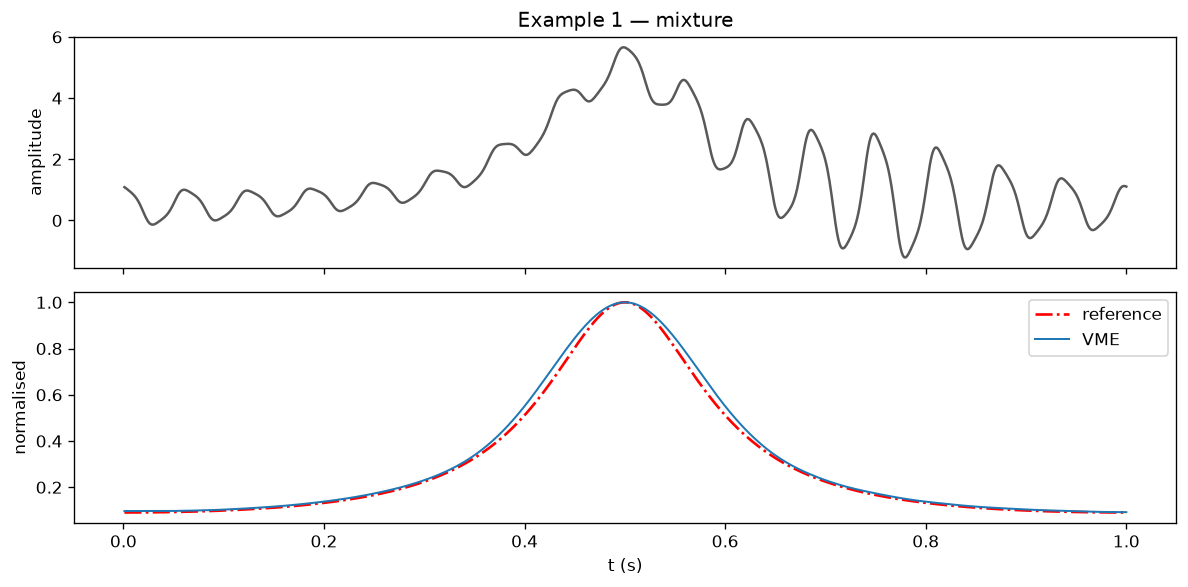

In [3]:
demo1 = generate_vme_example1()
mode1, omega1 = run_demo(demo1)

## 5. MATLAB / paper Example 2

Paper Eq. (24): a 2 Hz tone plus two AM tones at 15 Hz and 40 Hz.  MATLAB extracts the **15 Hz** component with `omega_init = 10` Hz.

Example 2: n_iter=7, omega = 14.997 Hz


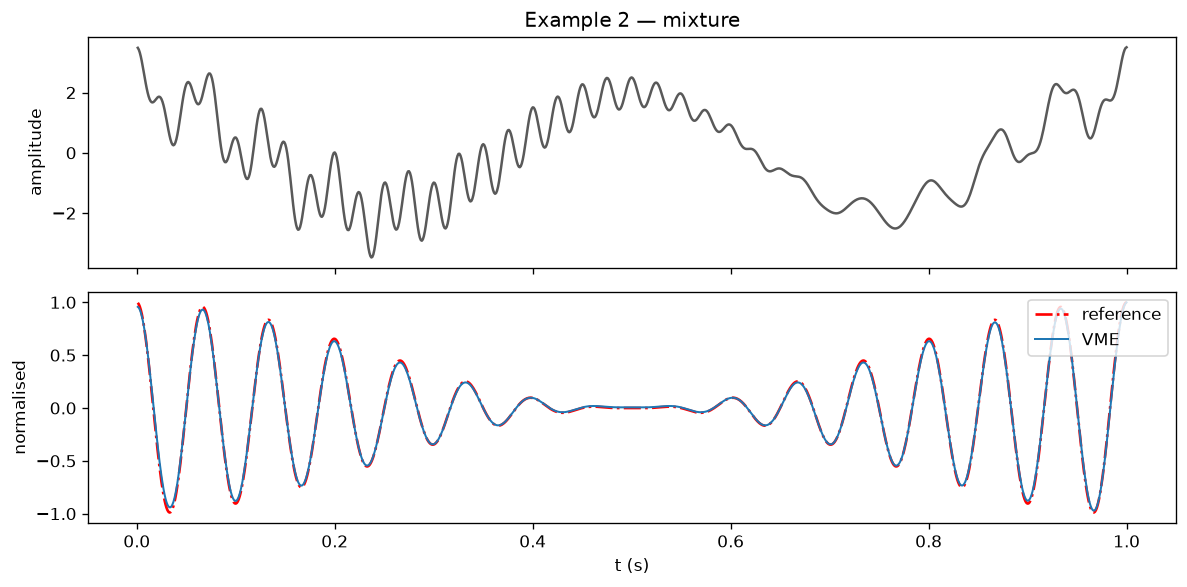

In [4]:
demo2 = generate_vme_example2()
mode2, omega2 = run_demo(demo2)

## 6. MATLAB / paper Example 3

Paper Eq. (25): a linear chirp (instantaneous frequency 5–15 Hz) plus a tone that jumps from 30 Hz to 50 Hz at $t=0.5$ s.

- **3a** — extract the chirp (`omega_init = 6` Hz).
- **3b** — extract the first piecewise tone (`omega_init = 26` Hz).

Example 3a: n_iter=20, omega = 10.030 Hz
Example 3b: n_iter=7, omega = 30.087 Hz


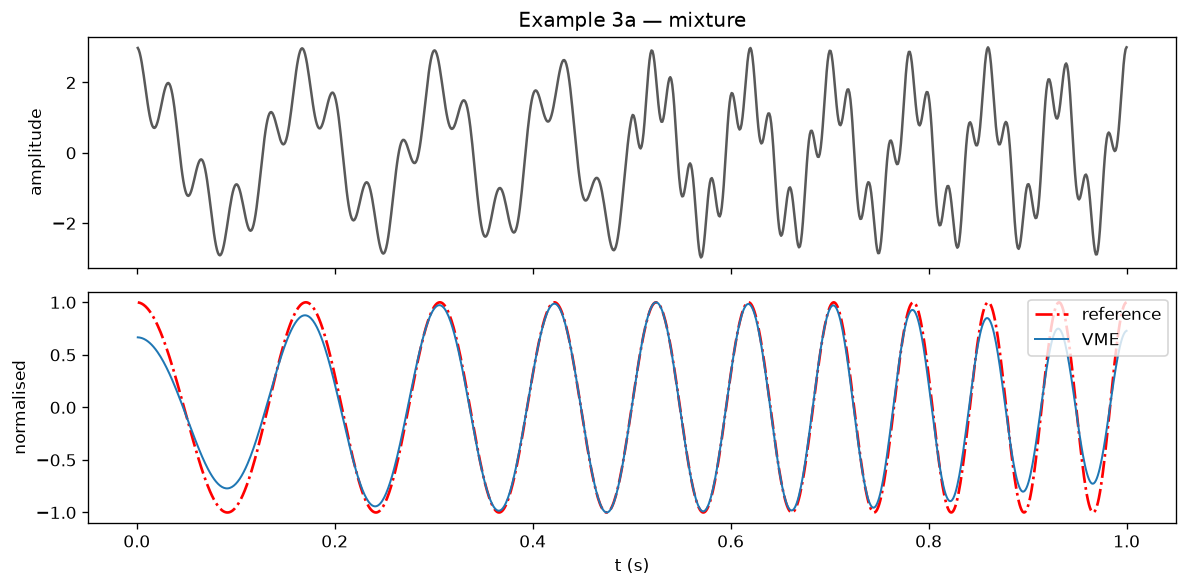

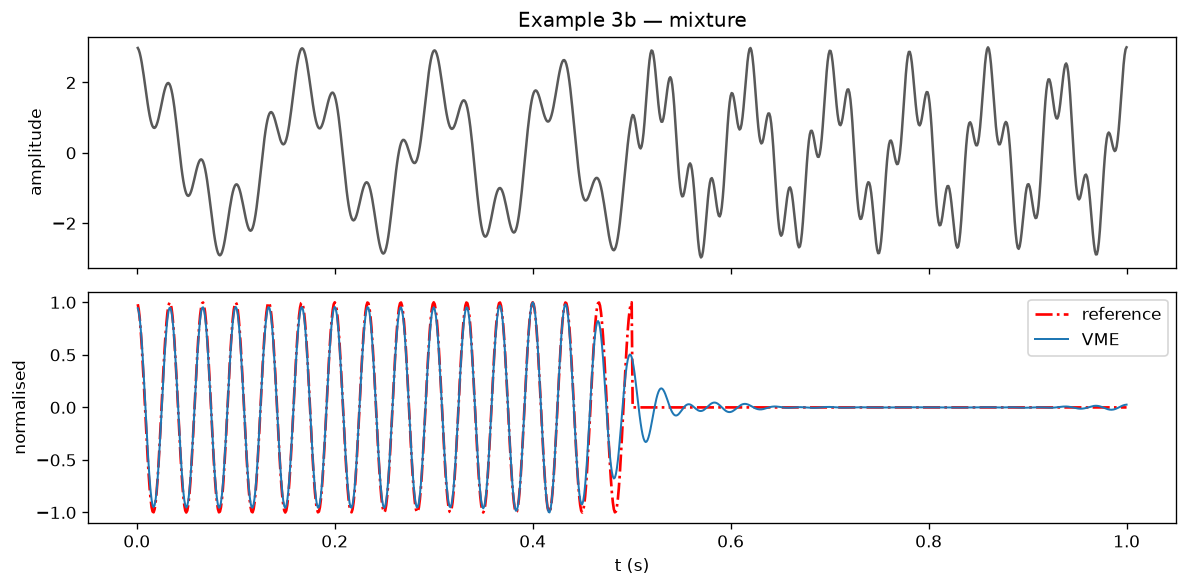

In [5]:
mode3a, omega3a = run_demo(generate_vme_example3a())
mode3b, omega3b = run_demo(generate_vme_example3b())

## 7. Real ECG: MIMIC record `055m`

The File Exchange archive ships `055m.mat` (`val` of shape `(7, 7500)`).  It is packaged with PySDKit as `pysdkit/_vmd/data/ecg_055m.npy` so the demo works from the PyPI wheel.

Following the paper (MIMIC, $f_s = 125$ Hz) and `VME_test_script.m`:

- channel 0 → ECG
- last channel → simultaneous reference respiration
- VME with `omega_init = 0` (respiration is the lowest-frequency ECG component) and `alpha = 20000`

The paper's Fig. 4 uses a **32 s / 4000-sample** window of record 055.

fs = 125 Hz, window = 32 s, omega = 0.051 Hz


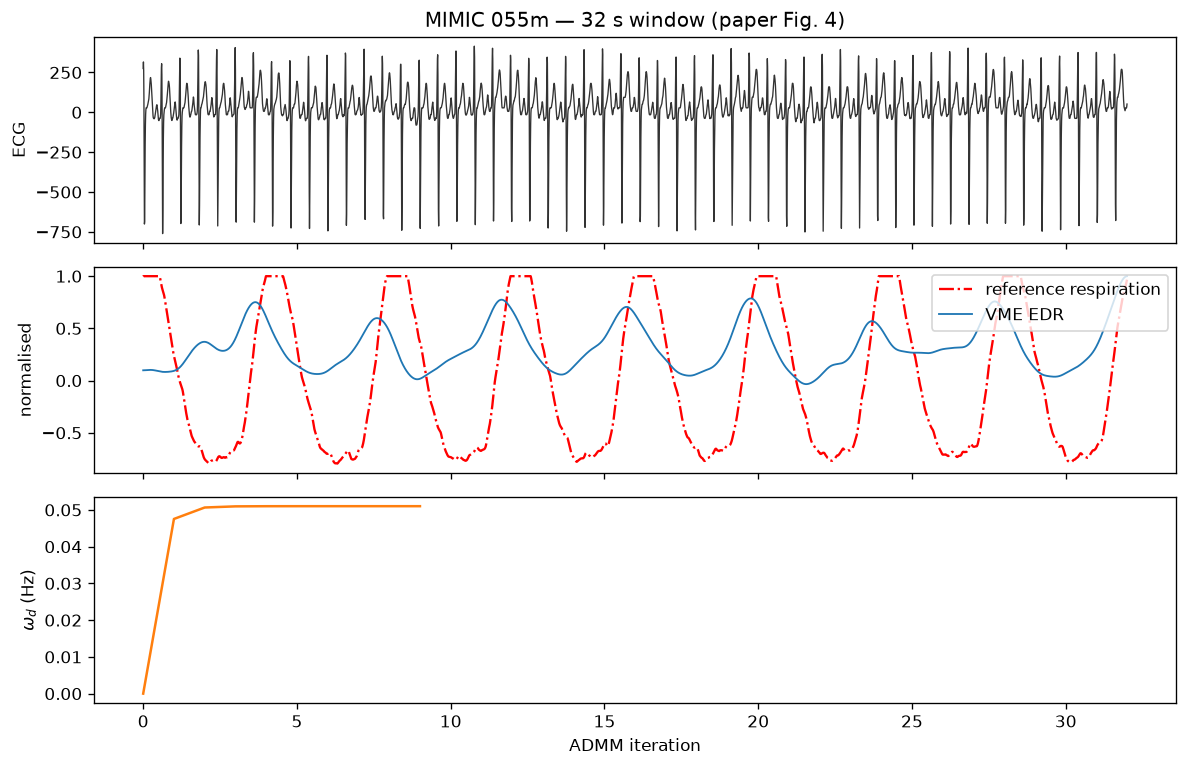

In [6]:
rec = load_vme_ecg_055m()
n = 4000
fs = float(rec["fs"])
t = rec["t"][:n]
ecg = rec["ecg"][:n]
resp = rec["respiration"][:n]

edr, _, omega_hist = VME(
    alpha=20000.0, omega_init=0.0, fs=fs, tau=0.0, tol=1e-7
).fit_transform(ecg, return_all=True)

print(f"fs = {fs:.0f} Hz, window = {n / fs:.0f} s, omega = {omega_hist[-1] * fs:.3f} Hz")

fig, axes = plt.subplots(3, 1, figsize=(10, 6.5), sharex=True)
axes[0].plot(t, ecg, color="0.2", lw=0.8)
axes[0].set_ylabel("ECG")
axes[0].set_title("MIMIC 055m — 32 s window (paper Fig. 4)")
axes[1].plot(t, resp / np.max(np.abs(resp)), "r-.", lw=1.4, label="reference respiration")
axes[1].plot(t, edr / np.max(np.abs(edr)), color="C0", lw=1.1, label="VME EDR")
axes[1].legend(loc="upper right")
axes[1].set_ylabel("normalised")
axes[2].plot(np.arange(omega_hist.size), omega_hist * fs, color="C1")
axes[2].set_xlabel("ADMM iteration")
axes[2].set_ylabel("$\\omega_d$ (Hz)")
fig.tight_layout()
plt.show()

## 8. Notes

- Odd-length inputs are truncated by one sample so MATLAB `T/2` indexing is well-defined.
- `tau = 0` is the recommended setting for noisy ECG (dual ascent is then skipped).
- For EDR, initialise at DC (`omega_init=0`).  For a mid-band interferer (e.g. 50/60 Hz mains), set `omega_init` near that frequency instead of running full VMD.
- Load the packaged record with `from pysdkit._vmd.vme import load_vme_ecg_055m`.
